In [2]:
from functools import partial
import jax
from jax import random
from jax import numpy as jnp
from matplotlib.pyplot import hist


@partial(jax.jit, static_argnums=(1,))
def mh_kernel(rng_key, prob_fn, prob_params, position, prob, step_size, PBC=10.0):
    key1, key2 = random.split(rng_key)
    proposal = position + random.uniform(
        key1, shape=position.shape, minval=-step_size, maxval=step_size
    )
    proposal = ((proposal + 0.5 * PBC) % PBC) - 0.5 * PBC
    proposal_prob = prob_fn(proposal, prob_params)
    accept_prob = jnp.minimum(1.0, proposal_prob / prob)
    accept = jax.random.uniform(key2) < accept_prob
    new_position = jnp.where(accept, proposal, position)
    new_prob = jnp.where(accept, proposal_prob, prob)
    acceptance_rate = jnp.mean(accept.astype(jnp.float32))
    return new_position, new_prob, acceptance_rate


@jax.jit
def adapt_step_size(step_size, accept, target=0.5, lr=0.01):
    # accept is a float 0.0 or 1.0
    # return step_size * jnp.exp(lr * (accept - target))
    return step_size


@partial(jax.jit, static_argnums=(1, 2, 3))
def mh_chain(rng_key, n_steps, PBC, prob_fn, prob_params, init_position, step_size=1.0):
    """MH single chain.

    If this chain is executed alone, then you obtain 1 single sample taken after n_steps.

    To obtain multiple samples, run multiple chains in parallel:

    sampler = jax.vmap(mh_chain, in_axes=(0, None, None, None, None, 0), out_axes=0)

    That means:
    - in_axes:
        - 0: different rng_key per chain
        - None: same n_steps for all chains
        - None: same PBC for all chains
        - None: same prob_fn for all chains
        - None: same prob_params per chain
        - 0: different init_position per chain
        - None: same step_size per chain

    INPUTS: 
    - rng_key: jax.random.PRNGKey
    - n_steps: int, number of MH steps to perform
    - PBC: float, periodic boundary conditions box size
    - prob_fn: function(position, prob_params) -> probability density at position
    - prob_params: parameters for prob_fn
    - init_position: jnp.array of shape (n_dim,), initial position of the chain
    - step_size: float, initial step size for proposals
    RETURNS:
    - positions: jnp.array of shape (n_steps, n_dim), sampled positions along the chain

    """

    def body_fn(val, _):
        key, position, prob, step_size = val
        key, subkey = random.split(key)
        new_position, new_prob, acceptance_rate = mh_kernel(
            subkey, prob_fn, prob_params, position, prob, step_size=step_size, PBC=PBC
        )
        step_size = adapt_step_size(step_size, acceptance_rate)
        _carry = (key, new_position, new_prob, step_size)
        return _carry, new_position

    init_prob = prob_fn(init_position, prob_params)
    init_val = (rng_key, init_position, init_prob, step_size)
    _, positions = jax.lax.scan(body_fn, init_val, None, length=n_steps)
    return positions


In [10]:
print("This is the qvarnet.sampler module.")
print("TESTING PLAYGROUND FOR THE SAMPLER MODULE")

key = random.PRNGKey(0)

def test_prob_fn(x, params):
    return jnp.exp(-0.5 * jnp.sum((x) ** 2, axis=-1))

sampler = jax.vmap(mh_chain, in_axes=(0, None, None, None, 0, 0), out_axes=0)
n_chains = 1
DoF = 1
n_steps = 10000
PBC = 20
print("CONFIG USED:")
print(f"n_chains: {n_chains}, DoF: {DoF}, n_steps: {n_steps}")
rng_keys = random.split(random.PRNGKey(872643), n_chains)
init_positions = jax.random.normal(random.PRNGKey(0), (n_chains, DoF)) * 2.0
samples = sampler(rng_keys, n_steps, PBC, test_prob_fn, None, init_positions)
print("Samples shape:", samples.shape)  # (n_chains, DoF)
average_position = jnp.mean(samples.reshape(-1, DoF), axis=0)
print("Average position over all samples:", average_position)
std_position = jnp.std(samples.reshape(-1, DoF), axis=0)
print("Std position over all samples:", std_position)

print("THEORETICAL VALUES:")
print("Average position: 0.0, 0.0")
print("Std position: 1.0, 1.0")

This is the qvarnet.sampler module.
TESTING PLAYGROUND FOR THE SAMPLER MODULE
CONFIG USED:
n_chains: 1, DoF: 1, n_steps: 10000
Samples shape: (1, 10000, 1)
Average position over all samples: [-0.00015611]
Std position over all samples: [0.9702813]
THEORETICAL VALUES:
Average position: 0.0, 0.0
Std position: 1.0, 1.0


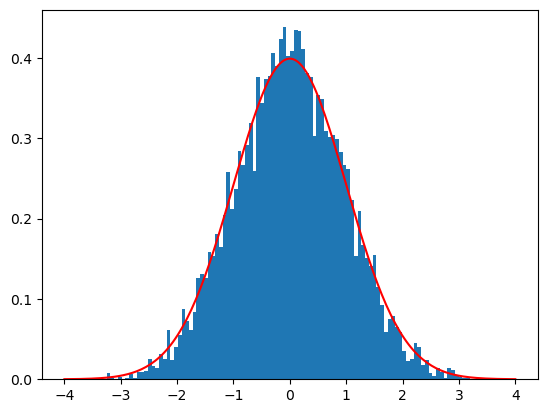

In [12]:
import matplotlib.pyplot as plt
plt.hist(samples.reshape(-1), bins=100, density=True);
def analytical_pdf(x):
    return (1.0 / jnp.sqrt(2 * jnp.pi)) * jnp.exp(-0.5 * x**2)
x = jnp.linspace(-4, 4, 200)
plt.plot(x, analytical_pdf(x), color='red', label='Analytical PDF')